In [1]:
import sys
sys.path.insert(0, '../')

In [2]:
%load_ext autoreload
%autoreload 2
#%matplotlib inline
from dpe import DPE
from lib_data import *
from lib_nn_dpe import NN_dpe
import matplotlib.pyplot as plt
import numpy as np
# from lib_nn_dpe import NN_dpe
from IPython import display
import math
import serial

from tqdm.notebook import tqdm
#%config InlineBackend.figure_formats = ['svg']

#import matplotlib
#matplotlib.rcParams['font.sans-serif'] = "Arial"

In [3]:
dpe = DPE('COM3')
dpe.set_clock(50)

DAC initialized to a span from -10 V to 10 V
Setting ADC_CK freq=50000.0kHz
Setting CK_ARRAY freq=50000.0kHz


....

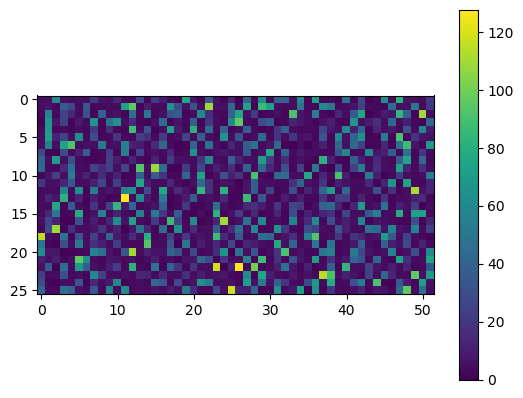

In [4]:
g = dpe.read(1, method='slow')
plt.imshow(g[14:40,12:64] * 1e6)
plt.colorbar()

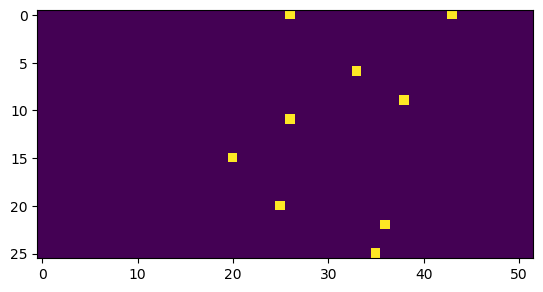

In [5]:
Stuck = np.zeros((64,64))
Stuck[g==0] = 1
plt.imshow(Stuck[14:40,12:64])

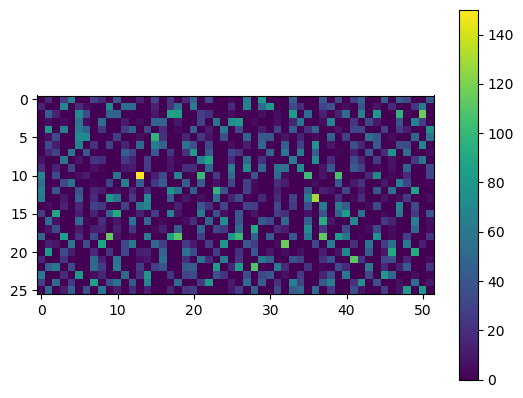

In [6]:
wq_head12_ssm = np.load('hpe/20261003/ToSuperT/target_conductance/WK_differential_interleaved.npy')
Gtarget = np.zeros((64,64))
Gtarget[14:40,12:64] = wq_head12_ssm *1e-6
plt.imshow(Gtarget[14:40,12:64]*1e6)
plt.colorbar()

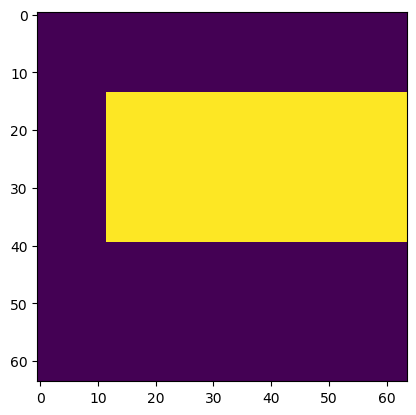

In [7]:
mask = np.zeros((64,64))
mask[14:40,12:64] = 1
plt.imshow(mask)

In [8]:
HistData = dpe.tune_conductance(1,Gtarget,Msel=mask, method='slow',Gtol_in=5e-6, Gtol_out=10e-6, vSetRamp=[0.6,2.7,0.03],vGateSetRamp=[1.15,2,0.05],vResetRamp=[0.6,2.5,0.02],vGateResetRamp=[5.0, 5.5, 0.5],TwidthSet=100e-6,TwidthReset=1e-3,maxSteps=300,saveHistory=True)

Start programming, step=299, maxBound=0 yield= 76.18% - 97.86%
33.0 devices to be programmed...reset 16.0, set 17.0
Setting 17 devices...
Programming with external timing Twidth=100.000 us
Resetting 16 devices...
Programming with external timing Twidth=1000.000 us


....

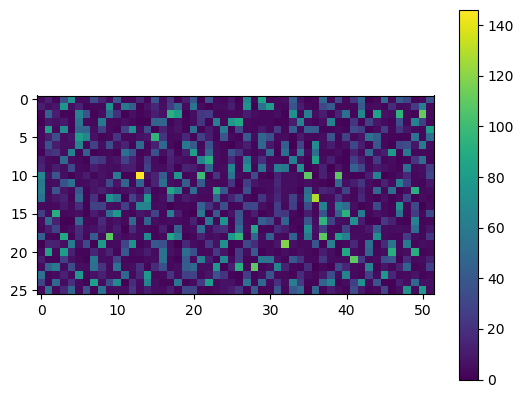

In [9]:
g_after_program = dpe.read(1, method='slow')
plt.imshow(g_after_program[14:40,12:64]*1e6)
plt.colorbar()


Conductance error mean: 1.66 μs, std: 5.36 μs


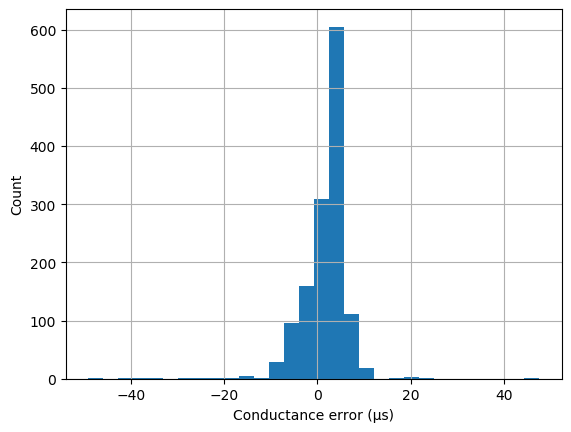

In [10]:
error = g_after_program[14:40,12:64]*1e6 - Gtarget[14:40,12:64]*1e6
error_mean = np.mean(error.reshape(-1))
error_std = np.std(error.reshape(-1))
print(f'Conductance error mean: {error_mean:.2f} μs, std: {error_std:.2f} μs')
plt.hist(error.reshape(-1),bins=30)
plt.xlabel('Conductance error (μs)')  # 横坐标：电导差，单位微秒
plt.ylabel('Count')  # 纵坐标：数量
plt.grid(True)
plt.show()

In [11]:
np.save('hpe/20261003/FromSuperT/g_after_program_wk.npy', g_after_program[14:40,12:64])

In [12]:
X = np.load("hpe/20261003/ToSuperT/input/X_all_positions.npy")   # 有符号
scale_x = np.abs(X).max()                 # 全局缩放，保留相对幅度
Xp = np.clip( X, 0, None) / scale_x       # 正部，∈[0,1]
Xn = np.clip(-X, 0, None) / scale_x       # 负部，∈[0,1]
# Xp = Xp[:100,:]  # 取前100个样本
# Xn = Xn[:100,:]  # 取前100个样本
X_eff = Xp - Xn                          
output_soft = X_eff @ Gtarget[14:40,12:64]

In [13]:
dpe.N_BIT = 8
raw_p = dpe.multiply(1, Xp.T, r_start=14, c_sel=[12,64], mode=0, debug=False, Tdly=1000, raw=False)
raw_n = dpe.multiply(1, Xn.T, r_start=14, c_sel=[12,64], mode=0, debug=False, Tdly=1000, raw=False)
rawOutput = raw_p - raw_n                 # = X_eff @ G

....

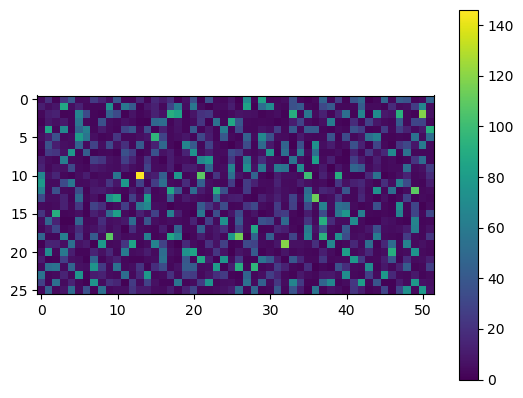

In [14]:
g_after_mult = dpe.read(1, method='slow')
plt.imshow(g_after_mult[14:40,12:64]*1e6)
plt.colorbar()

In [15]:
np.save('hpe/20261003/FromSuperT/g_after_mult_wk.npy', g_after_mult[14:40,12:64])

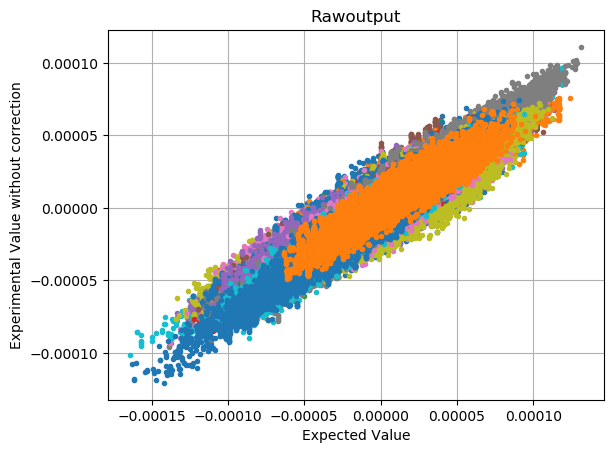

In [16]:
for c in range(rawOutput.shape[1]):
    plt.plot(output_soft[:,c], rawOutput[:,c], '.')
plt.title('Rawoutput')

plt.xlabel('Expected Value')

plt.ylabel('Experimental Value without correction')
plt.grid(True)
plt.show()

In [17]:
np.save('hpe/20261003/FromSuperT/out_mult_wk_raw.npy', rawOutput)

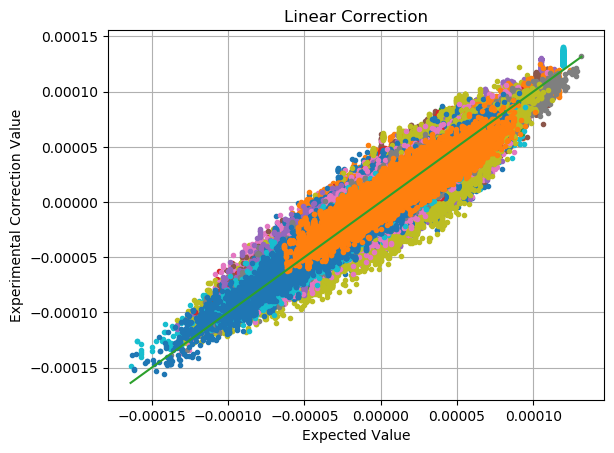

In [18]:
lin_cor_conv = []
for c in range(rawOutput.shape[1]):
    lin_cor_conv.append( np.polyfit(rawOutput[:,c], output_soft[:,c], 1))

quodra_cor_conv = []
for c in range(rawOutput.shape[1]):
    quodra_cor_conv.append(np.polyfit(rawOutput[:,c], output_soft[:,c], 2))

min_value = min(np.min(output_soft), np.min(rawOutput))
max_value = max(np.max(output_soft), np.max(rawOutput))
x_data = np.linspace(min_value, max_value, 100)


output_dif_cor = dpe.lin_corr(rawOutput, lin_cor_conv)
# output_dif_cor = dpe.quodra_fit(rawOutput, quodra_cor_conv)

for c in range(output_dif_cor.shape[1]):
    plt.plot(output_soft[:,c], output_dif_cor[:,c], '.')

plt.plot(x_data, x_data, label='y = x')
# 添加标题
plt.title('Linear Correction')

# 添加横轴标签
plt.xlabel('Expected Value')

# 添加纵轴标签
plt.ylabel('Experimental Correction Value')

# 显示网格
plt.grid(True)
# 显示图形
plt.show()

In [19]:
output_dif_cor.shape
np.save('hpe/20261003/FromSuperT/out_mult_wk_raw_linear_corr.npy', output_dif_cor)

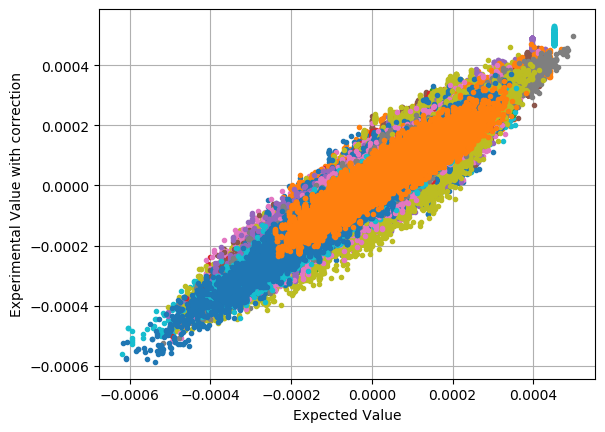

In [20]:
output_soft_original = output_soft * scale_x
output_exp_original = output_dif_cor * scale_x

for c in range(output_exp_original.shape[1]):
    plt.plot(output_soft_original[:,c], output_exp_original[:,c], '.')

plt.xlabel('Expected Value')

plt.ylabel('Experimental Value with correction')
plt.grid(True)
plt.show()

In [21]:
np.save('hpe/20261003/FromSuperT/out_mult_wk_linear_corr.npy', output_exp_original)